# Phân Tích Dữ Liệu Thị Trường Cà Phê (EDA)



In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

In [17]:


def load_and_preprocess_coffee(filepath):
  
    with open(filepath, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    cleaned_lines = [line.strip().strip('"') for line in lines]
    
  
    raw_csv_string = '\n'.join(cleaned_lines)
  
    df = pd.read_csv(io.StringIO(raw_csv_string), thousands=',')
    

    df.columns = df.columns.str.strip()

    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    
  
    def parse_volume(vol_str):
        vol_str = str(vol_str).strip().upper()
        if vol_str in ['NAN', '-', '']: return 0.0
        if 'K' in vol_str: return float(vol_str.replace('K', '')) * 1000
        if 'M' in vol_str: return float(vol_str.replace('M', '')) * 1000000
        return float(vol_str.replace(',', ''))
        
    if 'Vol.' in df.columns:
        df['Vol.'] = df['Vol.'].apply(parse_volume)
        

    if 'Change %' in df.columns:
        df['Change %'] = df['Change %'].astype(str).str.replace('%', '').astype(float)
        
    # 4. Đảm bảo tất cả các cột giá đều là float (phòng trường hợp Pandas miss mất do ký tự lạ)
    price_cols = ['Price', 'Open', 'High', 'Low', 'Gia_Viet_Nam']
    for col in price_cols:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '').astype(float)
            
   
    # Sắp xếp chuỗi thời gian từ quá khứ đến hiện tại
    df = df.sort_values('Date').reset_index(drop=True)
    
    return df

arabica_df = load_and_preprocess_coffee('../data/arabica.csv')
robusta_df = load_and_preprocess_coffee('../data/robusta.csv')


print("--- Dữ liệu Arabica ---")
display(arabica_df.head())

print("\n--- Dữ liệu Robusta ---")
display(robusta_df.head())

--- Dữ liệu Arabica ---


,Date,Price,Open,High,Low,Vol.,Change %,Gia_Viet_Nam
0,2023-03-01,185.30,188.00,188.00,185.00,50.0,-2.68,107316.202226
1,2023-03-02,183.95,185.00,186.40,180.55,18460.0,-0.73,106534.351859
2,2023-03-03,180.80,181.00,181.70,180.40,10.0,-1.71,104710.034336
3,2023-03-06,182.45,180.80,182.00,180.60,10.0,0.91,105665.629229
4,2023-03-07,184.55,182.15,182.15,182.15,0.0,1.15,106881.840911



--- Dữ liệu Robusta ---


,Date,Price,Open,High,Low,Vol.,Change %,Gia_Viet_Nam
0,2023-03-01,2177.0,2135.0,2190.0,2119.0,11960.0,1.73,57189.79
1,2023-03-02,2180.0,2176.0,2191.0,2165.0,6730.0,0.14,57268.60
2,2023-03-03,2162.0,2176.0,2186.0,2151.0,6600.0,-0.83,56795.74
3,2023-03-06,2153.0,2160.0,2171.0,2135.0,7550.0,-0.42,56559.31
4,2023-03-07,2152.0,2159.0,2162.0,2125.0,8810.0,-0.05,56533.04


##  Chuẩn hóa Đơn vị về VND/kg

Để so sánh công bằng giữa hai loại cà phê, toàn bộ dữ liệu giá được quy đổi sang **VND/kg** bằng tỷ giá cố định `USD/VND = 25,400`.

### Công thức quy đổi

| Loại cà phê | Đơn vị gốc | Hệ số chuyển đổi | Đơn vị sau |
|---|---|---|---|
| **Arabica** | Cents/lb | `× 22.0462 × 25,400 ÷ 1,000` | VND/kg |
| **Robusta** | USD/Tấn | `× 25,400 ÷ 1,000` | VND/kg |

> 💡 **Giải thích**: 1 pound ≈ 0.4536 kg, nên 1 USD/lb = 22.0462 USD/Tấn. Nhân tỷ giá rồi chia 1000 để ra VND/kg.

In [18]:

USDVND = 25400


cols_to_convert = ['Price', 'Open', 'High', 'Low']


arabica_factor = (22.0462 * USDVND) / 1000

for col in cols_to_convert:
    if col in arabica_df.columns:
        arabica_df[col] = arabica_df[col] * arabica_factor


robusta_factor = USDVND / 1000

for col in cols_to_convert:
    if col in robusta_df.columns:
        robusta_df[col] = robusta_df[col] * robusta_factor


arabica_df=arabica_df.drop(columns=['Gia_Viet_Nam'], errors='ignore')
robusta_df=robusta_df.drop(columns=['Gia_Viet_Nam'], errors='ignore')
print("--- Dữ liệu Arabica (Đã chuyển về VND/kg) ---")
display(arabica_df.head(3))

print("\n--- Dữ liệu Robusta (Đã chuyển về VND/kg) ---")
display(robusta_df.head(3))
arabica_df.to_csv('../data/arabica_vnd.csv', index=False)
robusta_df.to_csv('../data/robusta_vnd.csv', index=False)


--- Dữ liệu Arabica (Đã chuyển về VND/kg) ---


,Date,Price,Open,High,Low,Vol.,Change %
0,2023-03-01,103763.085844,105275.01424,105275.014240,103595.093800,50.0,-2.68
1,2023-03-02,103007.121646,103595.09380,104379.056672,101103.211814,18460.0,-0.73
2,2023-03-03,101243.205184,101355.19988,101747.181316,101019.215792,10.0,-1.71



--- Dữ liệu Robusta (Đã chuyển về VND/kg) ---


,Date,Price,Open,High,Low,Vol.,Change %
0,2023-03-01,55295.8,54229.0,55626.0,53822.6,11960.0,1.73
1,2023-03-02,55372.0,55270.4,55651.4,54991.0,6730.0,0.14
2,2023-03-03,54914.8,55270.4,55524.4,54635.4,6600.0,-0.83


## 1. Biểu đồ : Nến Nhật & Khối lượng Giao dịch

### Mô tả biểu đồ
Biểu đồ tương tác 2 hàng, có nút chuyển đổi giữa **Arabica** và **Robusta**:
- **Hàng trên (70%)**: Biểu đồ nến Nhật (Candlestick) — mỗi nến biểu diễn `Open`, `High`, `Low`, `Close (Price)` trong một phiên giao dịch
  - 🟢 **Nến xanh**: Giá đóng cửa ≥ giá mở cửa (phiên tăng)
  - 🔴 **Nến đỏ**: Giá đóng cửa < giá mở cửa (phiên giảm)
- **Hàng dưới (30%)**: Biểu đồ cột khối lượng giao dịch (`Vol.`), tô màu xanh/đỏ tương ứng với nến

### Nhận xét
- Giai đoạn **2023-2024**: Arabica giao dịch trong vùng **~100,000 – 150,000 VND/kg**, khối lượng ổn định
- Giai đoạn **2024-2025**: Giá Arabica tăng mạnh lên vùng **200,000+ VND/kg**, biên độ nến rộng hơn cho thấy biến động cao hơn
- Robusta duy trì vùng giá thấp hơn (~55,000 – 140,000 VND/kg) và có biên độ biến động hẹp hơn

In [19]:



arabica_colors = ['green' if price >= open_val else 'red' for price, open_val in zip(arabica_df['Price'], arabica_df['Open'])]
robusta_colors = ['green' if price >= open_val else 'red' for price, open_val in zip(robusta_df['Price'], robusta_df['Open'])]

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.03, row_heights=[0.7, 0.3])



fig.add_trace(go.Candlestick(x=arabica_df['Date'],
                open=arabica_df['Open'], high=arabica_df['High'],
                low=arabica_df['Low'], close=arabica_df['Price'],
                increasing_line_color='green', decreasing_line_color='red',
                name='Arabica Price'), 
                row=1, col=1)

fig.add_trace(go.Bar(x=arabica_df['Date'], y=arabica_df['Vol.'],
                marker_color=arabica_colors, name='Arabica Volume'), 
                row=2, col=1)


fig.add_trace(go.Candlestick(x=robusta_df['Date'],
                open=robusta_df['Open'], high=robusta_df['High'],
                low=robusta_df['Low'], close=robusta_df['Price'],
                increasing_line_color='green', decreasing_line_color='red',
                name='Robusta Price', visible=False), 
                row=1, col=1)

fig.add_trace(go.Bar(x=robusta_df['Date'], y=robusta_df['Vol.'],
                marker_color=robusta_colors, name='Robusta Volume', visible=False), 
                row=2, col=1)

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=1, y=1.1, # Vị trí của nút
            showactive=True,
            buttons=list([
                dict(label="Cà phê Arabica",
                     method="update",
                     args=[{"visible": [True, True, False, False]}, # Hiện trace 1,2; Ẩn trace 3,4
                           {"title": "Biểu đồ Nến & Khối lượng: Cà phê Arabica (VND/kg)"}]),
                dict(label="Cà phê Robusta",
                     method="update",
                     args=[{"visible": [False, False, True, True]}, # Ẩn trace 1,2; Hiện trace 3,4
                           {"title": "Biểu đồ Nến & Khối lượng: Cà phê Robusta (VND/kg)"}]),
            ]),
        )
    ]
)


fig.update_layout(
    title='Biểu đồ Nến & Khối lượng: Cà phê Arabica (VND/kg)',
    yaxis_title='Giá (VND/kg)',
    yaxis2_title='Khối lượng HĐ',
    xaxis_rangeslider_visible=False, # Tắt thanh trượt mặc định của Candlestick để nhìn gọn hơn
    template='plotly_dark', # Bạn có thể đổi thành 'plotly_white' nếu thích nền sáng
    height=800
)

fig.show()

##  2. Biểu đồ : Xu hướng Giá & Đường Trung bình Động (SMA)

### Mô tả biểu đồ
Biểu đồ 3 hàng, cùng chia sẻ trục thời gian và thanh trượt ở hàng cuối:

1. **Hàng 1 — So sánh xu hướng chung**: Vẽ đường giá Arabica (đỏ) và Robusta (xanh) trên cùng một đồ thị
2. **Hàng 2 — Phân tích kỹ thuật Robusta**: Giá thực tế + 3 đường SMA (7, 14, 30 ngày)
3. **Hàng 3 — Phân tích kỹ thuật Arabica**: Giá thực tế + 3 đường SMA (7, 14, 30 ngày)

### Ý nghĩa các đường SMA
| Đường | Ý nghĩa |
|---|---|
| **SMA 7** (cam) | Xu hướng ngắn hạn, phản ứng nhanh với biến động |
| **SMA 14** (xanh lá) | Xu hướng trung hạn, cân bằng giữa nhạy và ổn định |
| **SMA 30** (hồng) | Xu hướng dài hạn, lọc bỏ nhiễu thị trường |

### Nhận xét
- Cả Arabica và Robusta đều có **xu hướng tăng dài hạn** từ 2023 đến 2025
- Arabica tăng mạnh hơn và đạt đỉnh cao hơn (~230,000 VND/kg vào Q3/2025)
- Khi SMA 7 cắt lên trên SMA 30 → **tín hiệu mua** (Golden Cross); cắt xuống → **tín hiệu bán** (Death Cross)
- Hai loại cà phê có xu hướng di chuyển **cùng chiều** nhưng biên độ khác nhau

In [20]:



arabica_df = arabica_df.sort_values('Date')
robusta_df = robusta_df.sort_values('Date')

# Arabica
arabica_df['SMA_7'] = arabica_df['Price'].rolling(window=7).mean()
arabica_df['SMA_14'] = arabica_df['Price'].rolling(window=14).mean()
arabica_df['SMA_30'] = arabica_df['Price'].rolling(window=30).mean()

robusta_df['SMA_7'] = robusta_df['Price'].rolling(window=7).mean()
robusta_df['SMA_14'] = robusta_df['Price'].rolling(window=14).mean()
robusta_df['SMA_30'] = robusta_df['Price'].rolling(window=30).mean()


fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    subplot_titles=(
        "1. Xu hướng Giá chung: Arabica vs Robusta (VND/kg)",
        "2. Phân tích Kỹ thuật: Moving Averages (ROBUSTA)",
        "3. Phân tích Kỹ thuật: Moving Averages (ARABICA)"
    )
)

fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['Price'],
                         mode='lines', name='Giá Arabica', line=dict(color='indianred', width=2)),
              row=1, col=1)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['Price'],
                         mode='lines', name='Giá Robusta', line=dict(color='royalblue', width=2)),
              row=1, col=1)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['Price'],
                         mode='lines', name='Robusta Thực tế', line=dict(color='rgba(65, 105, 225, 0.4)', width=1, dash='dot')),
              row=2, col=1)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['SMA_7'],
                         mode='lines', name='R-SMA 7', line=dict(color='orange', width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['SMA_14'],
                         mode='lines', name='R-SMA 14', line=dict(color='green', width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['SMA_30'],
                         mode='lines', name='R-SMA 30', line=dict(color='magenta', width=2)), row=2, col=1)


fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['Price'],
                         mode='lines', name='Arabica Thực tế', line=dict(color='rgba(205, 92, 92, 0.4)', width=1, dash='dot')),
              row=3, col=1)

# Thêm chữ "A-" vào tên để phân biệt với Robusta trên Legend
fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['SMA_7'],
                         mode='lines', name='A-SMA 7', line=dict(color='orange', width=2)), row=3, col=1)
fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['SMA_14'],
                         mode='lines', name='A-SMA 14', line=dict(color='green', width=2)), row=3, col=1)
fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['SMA_30'],
                         mode='lines', name='A-SMA 30', line=dict(color='magenta', width=2)), row=3, col=1)

fig.update_layout(
    height=1000, # Tăng chiều cao tổng thể để 3 chart không bị ép cục lại
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Chuyển thanh trượt thời gian (rangeslider) xuống hàng cuối cùng (row=3)
fig.update_xaxes(rangeslider_visible=False, row=1, col=1)
fig.update_xaxes(rangeslider_visible=False, row=2, col=1)
fig.update_xaxes(rangeslider_visible=True, row=3, col=1, rangeslider_thickness=0.04)

fig.show()

## 3. Biểu đồ : Chênh lệch Giá (Spread) 

### Mô tả biểu đồ
Biểu đồ đường duy nhất thể hiện **Spread = Giá Arabica − Giá Robusta** (đơn vị: VND/kg) theo thời gian, kèm đường trung bình Spread làm mốc tham chiếu.

### Ý nghĩa
- **Spread dương**: Arabica đắt hơn Robusta (thường xuyên xảy ra do chất lượng khác nhau)
- **Spread tăng**: Arabica đang tăng giá nhanh hơn hoặc Robusta giảm
- **Spread giảm** (hội tụ về trung bình): Cơ hội arbitrage giảm dần

### Nhận xét
- Spread trung bình duy trì ở mức **~50,000 – 80,000 VND/kg**
- Cuối năm 2024 và 2025, Spread mở rộng mạnh khi Arabica bùng nổ


In [21]:


df_corr = pd.merge(
    arabica_df[['Date', 'Price', 'Vol.']], 
    robusta_df[['Date', 'Price', 'Vol.']], 
    on='Date', 
    suffixes=('_Arabica', '_Robusta')
)


df_corr = df_corr.dropna()


df_corr['Spread'] = df_corr['Price_Arabica'] - df_corr['Price_Robusta']

# Lấy giá trị Spread trung bình để làm đường mốc
mean_spread = df_corr['Spread'].mean()


fig1 = go.Figure()


fig1.add_trace(go.Scatter(
    x=df_corr['Date'], y=df_corr['Spread'],
    mode='lines',
    name='Mức chênh lệch (Spread)',
    line=dict(color='purple', width=2),
    fill='tonexty', # Đổ màu xuống đường trung bình
    fillcolor='rgba(128, 0, 128, 0.1)'
))


fig1.add_trace(go.Scatter(
    x=df_corr['Date'], y=[mean_spread] * len(df_corr),
    mode='lines',
    name=f'Trung bình: {mean_spread:,.0f} VND',
    line=dict(color='orange', width=2, dash='dash')
))

fig1.update_layout(
    title='BIỂU ĐỒ CHÊNH LỆCH GIÁ (SPREAD): ARABICA - ROBUSTA (VND/kg)',
    yaxis_title='Chênh lệch (VND/kg)',
    template='plotly_dark',
    height=500,
    hovermode='x unified'
)
fig1.show()



##  4. Biểu đồ : Biến động Nội ngày & Phân tích Khối lượng

### Mô tả biểu đồ
Dashboard 2 hàng:

**Hàng 1 — Biến động nội ngày (Intraday Volatility)**:
- Tính bằng `High − Low` mỗi phiên (VND/kg)
- So sánh biên độ dao động của Arabica (đỏ) và Robusta (xanh)

**Hàng 2 — Xác nhận xu hướng bằng khối lượng (Robusta)**:
- **Cột màu xanh/đỏ**: Khối lượng giao dịch từng phiên (trục trái)
- **Đường cam**: SMA 20 ngày của Volume, làm đường mốc trung bình
- **Đường trắng**: Giá đóng cửa (trục phải) — để xem liệu xu hướng giá có được xác nhận bởi volume không

### Nhận xét
- Arabica có **biên độ nội ngày lớn hơn** Robusta, phản ánh tính đầu cơ cao hơn
- Các đợt tăng/giảm giá mạnh thường đi kèm với **spike volume** — xác nhận tín hiệu xu hướng
- Volume Robusta ổn định và có xu hướng tăng theo giá, cho thấy xu hướng tăng được xác nhận

In [22]:




arabica_df['Intraday_Vol'] = arabica_df['High'] - arabica_df['Low']
robusta_df['Intraday_Vol'] = robusta_df['High'] - robusta_df['Low']

arabica_df['Vol_SMA_30'] = arabica_df['Vol.'].rolling(window=30).mean()
robusta_df['Vol_SMA_30'] = robusta_df['Vol.'].rolling(window=30).mean()


colors_robusta = ['green' if close >= open_p else 'red' for close, open_p in zip(robusta_df['Price'], robusta_df['Open'])]
colors_arabica = ['green' if close >= open_p else 'red' for close, open_p in zip(arabica_df['Price'], arabica_df['Open'])]



fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    specs=[[{"secondary_y": False}],
           [{"secondary_y": True}],
           [{"secondary_y": True}]],
    subplot_titles=(
        "1. Biến động nội ngày (Intraday Volatility): Độ 'giật cục' của giá trong 1 phiên",
        "2. Xác nhận Xu hướng bằng Khối lượng (ROBUSTA)",
        "3. Xác nhận Xu hướng bằng Khối lượng (ARABICA)"
    )
)


fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['Intraday_Vol'],
                         mode='lines', name='Biên độ Arabica', line=dict(color='indianred', width=1.5)),
              row=1, col=1)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['Intraday_Vol'],
                         mode='lines', name='Biên độ Robusta', line=dict(color='royalblue', width=1.5)),
              row=1, col=1)

fig.add_trace(go.Bar(x=robusta_df['Date'], y=robusta_df['Vol.'],
                     name='Vol Robusta', marker_color=colors_robusta, opacity=0.5),
              row=2, col=1, secondary_y=False)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['Vol_SMA_30'],
                         mode='lines', name='SMA 30 Vol (R)', line=dict(color='orange', width=2)),
              row=2, col=1, secondary_y=False)

fig.add_trace(go.Scatter(x=robusta_df['Date'], y=robusta_df['Price'],
                         mode='lines', name='Giá Robusta', line=dict(color='white', width=2)),
              row=2, col=1, secondary_y=True)


fig.add_trace(go.Bar(x=arabica_df['Date'], y=arabica_df['Vol.'],
                     name='Vol Arabica', marker_color=colors_arabica, opacity=0.5),
              row=3, col=1, secondary_y=False)

fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['Vol_SMA_30'],
                         mode='lines', name='SMA 30 Vol (A)', line=dict(color='yellow', width=2)),
              row=3, col=1, secondary_y=False)


fig.add_trace(go.Scatter(x=arabica_df['Date'], y=arabica_df['Price'],
                         mode='lines', name='Giá Arabica', line=dict(color='indianred', width=2)),
              row=3, col=1, secondary_y=True)



fig.update_layout(
    height=1100,
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.03, xanchor="right", x=1)
)



fig.update_yaxes(title_text="Biên độ dao động (VND)", row=1, col=1)

fig.update_yaxes(title_text="Khối lượng (HĐ)", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="Giá đóng cửa", row=2, col=1, secondary_y=True)
# Hàng 3 (Arabica)
fig.update_yaxes(title_text="Khối lượng (HĐ)", row=3, col=1, secondary_y=False)
fig.update_yaxes(title_text="Giá đóng cửa", row=3, col=1, secondary_y=True)

fig.show()

##  Biểu đồ : Phân tích Rủi ro & Phân phối Lợi nhuận

### Mô tả biểu đồ
Lưới 2×2 gồm 4 biểu đồ Seaborn/Matplotlib:

| Vị trí | Loại biểu đồ | Nội dung |
|---|---|---|
| Trên trái | Histogram + KDE | Phân phối `Change %` của Arabica |
| Trên phải | Histogram + KDE | Phân phối `Change %` của Robusta |
| Dưới trái | Boxplot | Nhận diện outlier — Arabica |
| Dưới phải | Boxplot | Nhận diện outlier — Robusta |

### Kết quả thống kê — Top 10 ngày biến động mạnh nhất

**Arabica** — Các ngày biến động lớn nhất:
| # | Ngày | Giá (VND/kg) | Thay đổi |
|---|---|---|---|
| 1 | 2025-09-17 | 217,578 | **-7.98%** |
| 2 | 2025-12-17 | 197,055 | -7.22% |
| 3 | 2023-11-30 | 109,195 | **+7.08%** |
| 4 | 2024-12-02 | 167,544 | -6.98% |
| 5 | 2024-07-09 | 141,113 | +6.69% |

**Robusta** — Biến động cực đoan hơn (lớn nhất -10.62%):
| # | Ngày | Giá (VND/kg) | Thay đổi |
|---|---|---|---|
| 1 | 2024-12-02 | 122,072 | **-10.62%** |
| 2 | 2025-07-14 | 88,011 | +9.31% |
| 3 | 2024-05-02 | 93,472 | -7.49% |
| 4 | 2024-11-27 | 139,598 | +7.47% |
| 5 | 2025-09-19 | 105,029 | -7.02% |

### Nhận xét
- Phân phối `Change %` của cả hai loại xấp xỉ **chuẩn (Normal)** với đỉnh tập trung quanh 0%
- **Arabica** có đuôi phân phối đối xứng hơn; **Robusta** có tail nặng hơn ở phía âm
- Boxplot cho thấy nhiều **outlier** ở cả hai phía, đặc biệt Robusta với ngày -10.62%
- Robusta có thể rủi ro hơn xét về **tail risk** (rủi ro đuôi phân phối)

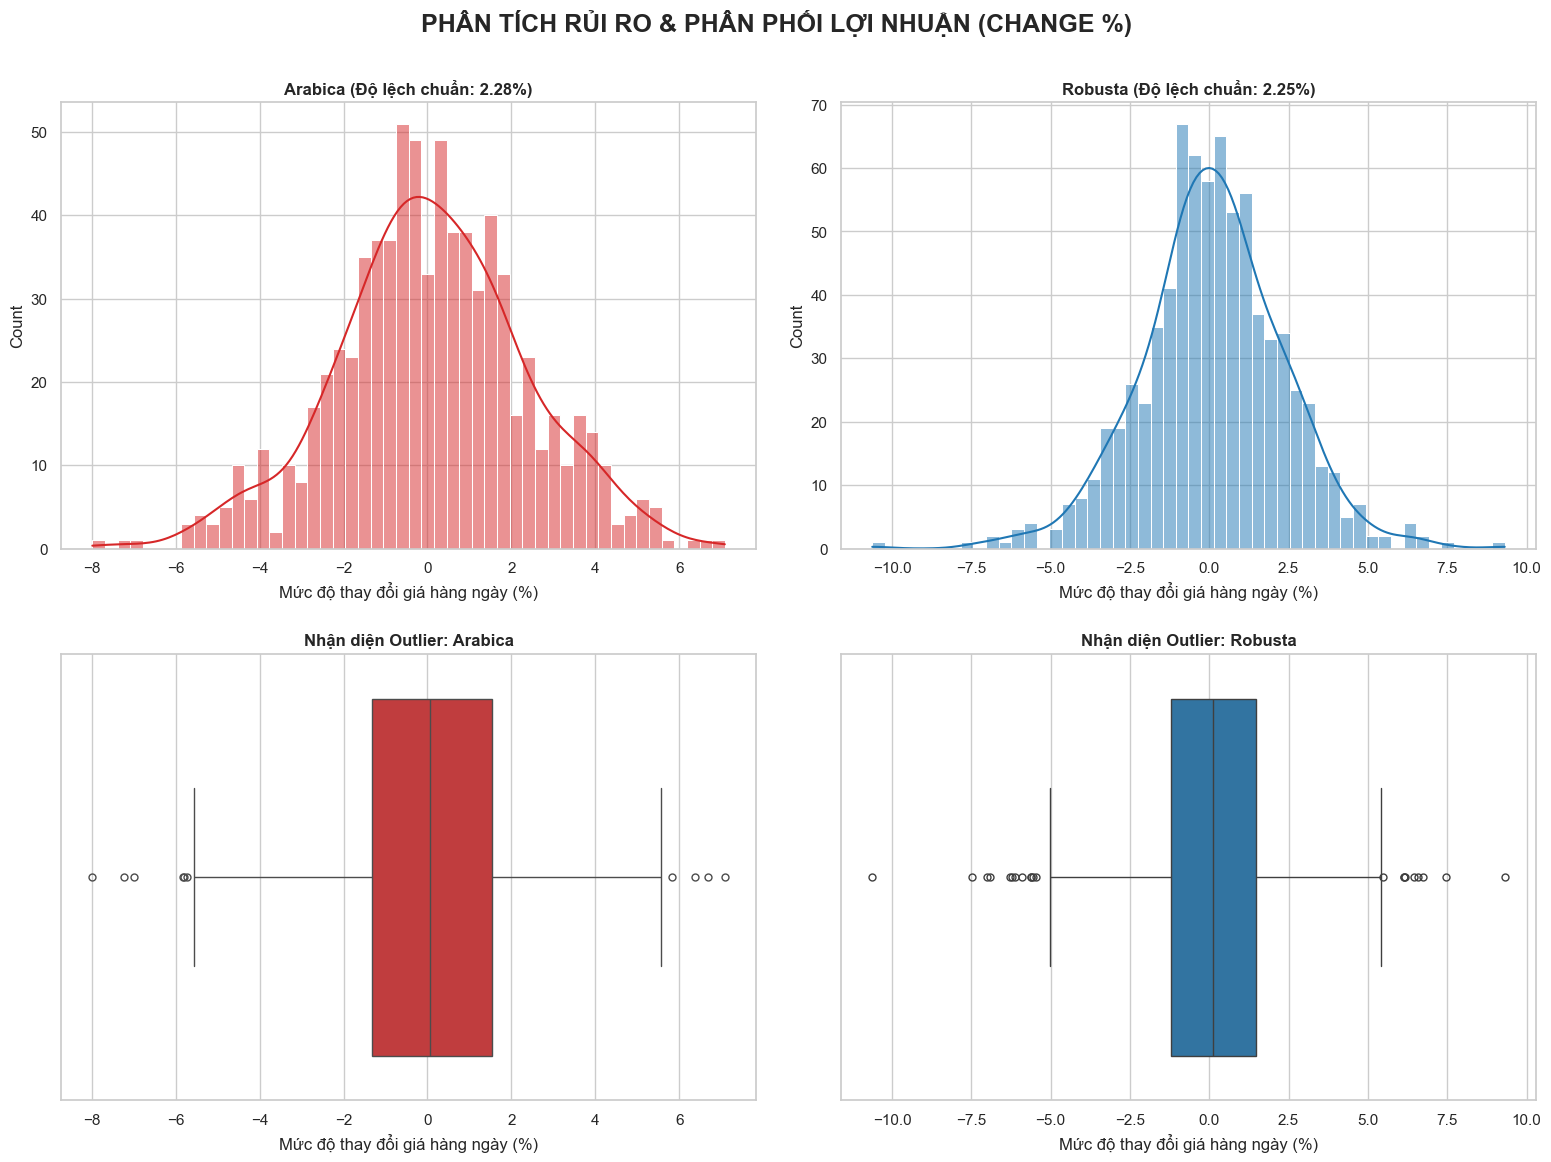

TOP 10 NGÀY BIẾN ĐỘNG MẠNH NHẤT: CÀ PHÊ ARABICA 


,Date,Price,Change %
0,2025-09-17,217577.695654,-7.98
1,2025-12-17,197054.667612,-7.22
2,2023-11-30,109194.828600,7.08
3,2024-12-02,167544.065216,-6.98
4,2024-07-09,141113.316960,6.69
5,2025-09-12,229953.109562,6.36
6,2023-12-20,106730.945288,-5.83
7,2024-05-28,129325.875206,5.82
8,2025-11-17,210886.012568,-5.80
9,2025-04-07,193078.855904,-5.72




TOP 10 NGÀY BIẾN ĐỘNG MẠNH NHẤT: CÀ PHÊ ROBUSTA 


,Date,Price,Change %
0,2024-12-02,122072.4,-10.62
1,2025-07-14,88011.0,9.31
2,2024-05-02,93472.0,-7.49
3,2024-11-27,139598.4,7.47
4,2025-09-19,105029.0,-7.02
5,2025-09-17,113030.0,-6.92
6,2024-05-21,94843.6,6.72
7,2024-07-09,117703.6,6.58
8,2025-08-20,111785.4,6.46
9,2025-06-18,97180.4,-6.27


In [23]:



sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PHÂN TÍCH RỦI RO & PHÂN PHỐI LỢI NHUẬN (CHANGE %)', fontsize=18, fontweight='bold')


arabica_change = arabica_df['Change %'].dropna()
robusta_change = robusta_df['Change %'].dropna()


sns.histplot(arabica_change, kde=True, ax=axes[0,0], color='tab:red', bins=50)
axes[0,0].set_title(f'Arabica (Độ lệch chuẩn: {arabica_change.std():.2f}%)', fontweight='bold')
axes[0,0].set_xlabel('Mức độ thay đổi giá hàng ngày (%)')

sns.histplot(robusta_change, kde=True, ax=axes[0,1], color='tab:blue', bins=50)
axes[0,1].set_title(f'Robusta (Độ lệch chuẩn: {robusta_change.std():.2f}%)', fontweight='bold')
axes[0,1].set_xlabel('Mức độ thay đổi giá hàng ngày (%)')


sns.boxplot(x=arabica_change, ax=axes[1,0], color='tab:red', fliersize=5)
axes[1,0].set_title('Nhận diện Outlier: Arabica', fontweight='bold')
axes[1,0].set_xlabel('Mức độ thay đổi giá hàng ngày (%)')

sns.boxplot(x=robusta_change, ax=axes[1,1], color='tab:blue', fliersize=5)
axes[1,1].set_title('Nhận diện Outlier: Robusta', fontweight='bold')
axes[1,1].set_xlabel('Mức độ thay đổi giá hàng ngày (%)')

plt.tight_layout(pad=2.0)
plt.show()



arabica_df['Abs_Change'] = arabica_df['Change %'].abs()
robusta_df['Abs_Change'] = robusta_df['Change %'].abs()


top_10_arabica = arabica_df.sort_values(by='Abs_Change', ascending=False).head(10)
top_10_robusta = robusta_df.sort_values(by='Abs_Change', ascending=False).head(10)

print("TOP 10 NGÀY BIẾN ĐỘNG MẠNH NHẤT: CÀ PHÊ ARABICA ")

display(top_10_arabica[['Date', 'Price', 'Change %']].reset_index(drop=True))

print("\n" + "="*50 + "\n")

print("TOP 10 NGÀY BIẾN ĐỘNG MẠNH NHẤT: CÀ PHÊ ROBUSTA ")
display(top_10_robusta[['Date', 'Price', 'Change %']].reset_index(drop=True))

---

##  Tổng kết EDA

### Những phát hiện chính

| Chủ đề | Arabica | Robusta |
|---|---|---|
| **Mức giá (VND/kg)** | 100,000 – 230,000 | 55,000 – 140,000 |
| **Xu hướng dài hạn** | Tăng mạnh 2023-2025 | Tăng, biên độ nhỏ hơn |
| **Biến động nội ngày** | Cao hơn | Thấp hơn |
| **Tail risk hàng ngày** | ~±7-8% | ~±10% |
| **Spread so với Robusta** | Luôn cao hơn | — |

